In [ ]:
# 4

In [18]:
!pip install -q langchain langchain-core langchain-groq

import os, subprocess, tempfile
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

os.environ["GROQ_API_KEY"] = "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"

llm = ChatGroq(model="openai/gpt-oss-20b")

generate = ChatPromptTemplate.from_messages([
    ("system", "Generate only executable Python code. No markdown or explanation."),
    ("user", "{task}")
]) | llm | StrOutputParser()

fix = ChatPromptTemplate.from_messages([
    ("system", "Fix the Python code using the error. Return only executable code."),
    ("user", "Task: {task}\nCode:\n{code}\nError:\n{error}")
]) | llm | StrOutputParser()


def run(code):
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as f:
        f.write(code)
        path = f.name

    r = subprocess.run(["python", path], capture_output=True, text=True)
    return r.returncode == 0, r.stdout or r.stderr


def assistant(task, attempts=3):
    code = generate.invoke({"task": task}).replace("```python", "").replace("```", "").strip()

    # Add an intentional error for demonstration
    if "factorial" in task.lower():
        code = code.replace("factorial(5)", "fact(5)")

    for i in range(attempts):
        print(f"\nAttempt {i + 1}:\n{code}")

        success, output = run(code)

        if success:
            print("\nOUTPUT:", output)
            print("FINAL CODE:\n", code)
            return

        print("\nERROR:", output)

        code = fix.invoke({
            "task": task,
            "code": code,
            "error": output
        }).replace("```python", "").replace("```", "").strip()

    print("\nCould not fix the code.")


assistant("Write a Python program to calculate the factorial of 5")


Attempt 1:
factorial = 1
n = 5
for i in range(1, n + 1):
    factorial *= i
print(factorial)

OUTPUT: 120

FINAL CODE:
 factorial = 1
n = 5
for i in range(1, n + 1):
    factorial *= i
print(factorial)


# 5

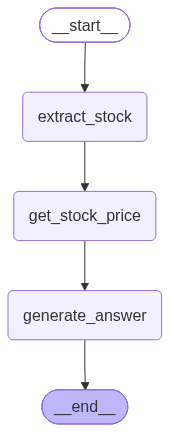

The current price of Microsoft (MSFT) stock is **$420.1**.


In [6]:
!pip install -q langgraph langchain langchain-core langchain-groq
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from IPython.display import Image, display
os.environ["GROQ_API_KEY"] = "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"
llm = ChatGroq(model="openai/gpt-oss-20b")
# 1. Define State
class FinanceState(TypedDict):
    question: str
    stock: str
    price: float
    answer: str
# 2. Node 1: Extract stock symbol
def extract_stock(state: FinanceState):
    question = state["question"].upper()
    if "APPLE" in question or "AAPL" in question:
        stock = "AAPL"
    elif "TESLA" in question or "TSLA" in question:
        stock = "TSLA"
    elif "MICROSOFT" in question or "MSFT" in question:
        stock = "MSFT"
    else:
        stock = "UNKNOWN"
    return {"stock": stock}
# 3. Node 2: Get stock price
def get_stock_price(state: FinanceState):
    fake_prices = {
        "AAPL": 195.50,
        "TSLA": 180.25,
        "MSFT": 420.10,
        "UNKNOWN": 0.0
    }
    price = fake_prices[state["stock"]]
    return {"price": price}
# 4. Node 3: Generate answer
def generate_answer(state: FinanceState):
    prompt = f"""
    You are a finance assistant.
    User question: {state['question']}
    Stock symbol: {state['stock']}
    Stock price: {state['price']}
    Give a simple financial response.
    Do not give investment advice.
    """
    response = llm.invoke(prompt)
    return {"answer": response.content}
# 5. Build LangGraph
graph = StateGraph(FinanceState)
graph.add_node("extract_stock", extract_stock)
graph.add_node("get_stock_price", get_stock_price)
graph.add_node("generate_answer", generate_answer)
graph.add_edge(START, "extract_stock")
graph.add_edge("extract_stock", "get_stock_price")
graph.add_edge("get_stock_price", "generate_answer")
graph.add_edge("generate_answer", END)
finance_bot = graph.compile()
display(
    Image(finance_bot.get_graph().draw_mermaid_png())
)
# 6. Run Finance Bot
result = finance_bot.invoke({
    "question": "What is the current price of MICROSOFT stock?"
})
print(result["answer"])